##Multiple Linear Regression (MLR)
**Multiple Linear Regression is an extension of Simple Linear Regression.
Simple Linear Regression uses 1 independent variable (X) to predict Y.
Multiple Linear Regression uses 2 or more independent variables (X₁, X₂, X₃, …) to predict Y.
Formula
y^​=β0​+β1​x1​+β2​x2​+β3​x3​+⋯+βn​xn​y^​=β0​+β1​x1​+β2​x2​+β3​x3​+⋯+βn​xn​**

**matrix representation**


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [58]:
data_df = pd.read_csv(
    "https://www.statlearning.com/s/Advertising.csv",
    index_col = 0)

In [59]:
print(type(data_df))

<class 'pandas.core.frame.DataFrame'>


In [60]:
data_df.head(200)

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


In [61]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


In [62]:
from matplotlib import gridspec

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(1, 3)

<Figure size 1200x800 with 0 Axes>

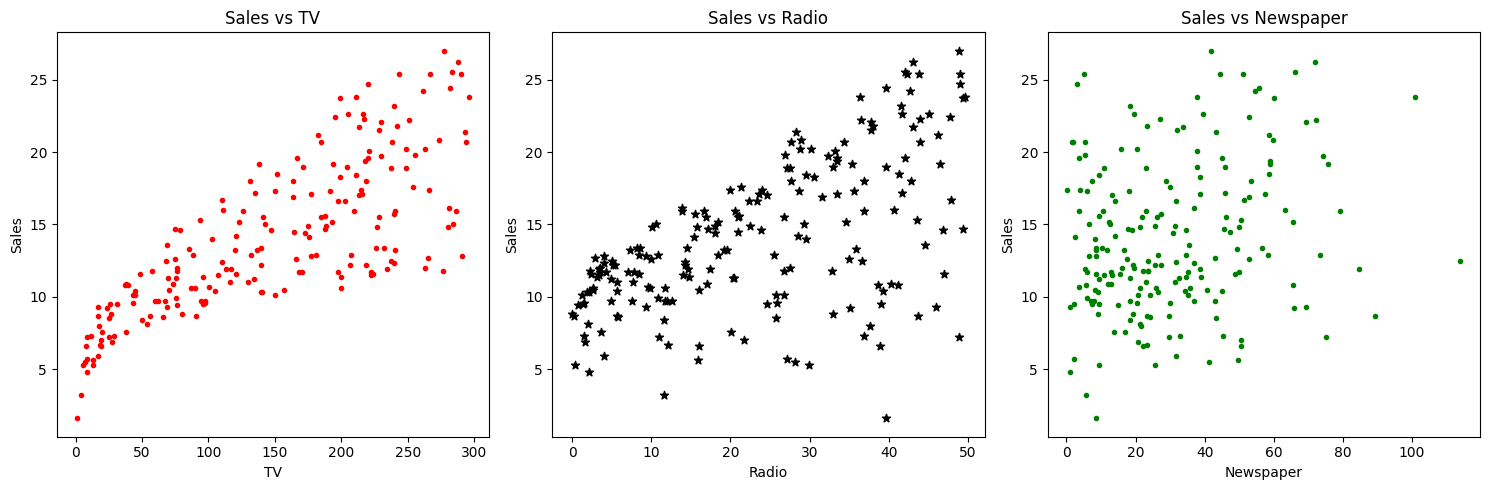

In [63]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Create a figure
fig = plt.figure(figsize=(15, 5))

# Create GridSpec with 1 row and 3 columns
gs = GridSpec(1, 3)

# Plot 1: Sales vs TV
ax = fig.add_subplot(gs[0])
ax.scatter(data_df["TV"], data_df["sales"], color="red", marker=".")
ax.set_xlabel("TV")
ax.set_ylabel("Sales")
ax.set_title("Sales vs TV")

# Plot 2: Sales vs Radio
ax = fig.add_subplot(gs[1])
ax.scatter(data_df["radio"], data_df["sales"], color="black", marker="*")
ax.set_xlabel("Radio")
ax.set_ylabel("Sales")
ax.set_title("Sales vs Radio")

# Plot 3: Sales vs Newspaper
ax = fig.add_subplot(gs[2])
ax.scatter(data_df["newspaper"], data_df["sales"], color="green", marker=".")
ax.set_xlabel("Newspaper")
ax.set_ylabel("Sales")
ax.set_title("Sales vs Newspaper")

plt.tight_layout()
plt.show()

In [64]:
from IPython.display import display, Math
X = data_df[["TV", "radio", "newspaper"]]
y = data_df["sales"]


multiple linear regression normal equation (y=β0​+β1​x1​+β2​x2​+β3​x3​)

In [65]:
X= np.c_[np.ones((200,1)), X] # c = columnwise concatenation

In [66]:
X_transpose = np.transpose(X)

In [67]:
X_transpose.shape

(4, 200)

This line of code calculates the regression coefficients (β values) for Ordinary Least Squares (OLS) using the Normal Equation.

The mathematical formula is:

β=(X
T
X)
−1
X
T
y

In [68]:
# ordinary least squares
betas = np.linalg.inv(X_transpose.dot(X)).dot(X_transpose).dot(y)

In [69]:
betas

array([ 2.93888937e+00,  4.57646455e-02,  1.88530017e-01, -1.03749304e-03])

In [70]:
from IPython.display import display, Math

display(Math(r"\mathbf{TV,\ Radio,\ and\ Newspaper}"))

display(
    Math(
        rf"y = {betas[0]:.2f}"
        rf"{betas[1]:+.2f}x_1"
        rf"{betas[2]:+.2f}x_2"
        rf"{betas[3]:+.2f}x_3"
    )
)

display(Math(r"x_1=\mathrm{TV}"))
display(Math(r"x_2=\mathrm{Radio}"))
display(Math(r"x_3=\mathrm{Newspaper}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

train test split

In [71]:
from sklearn.model_selection import train_test_split

X = data_df[["TV", "radio", "newspaper"]]
y = data_df["sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear regression

In [72]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [73]:
x = data_df[["TV", "radio", "newspaper"]].to_numpy()
y = data_df[["sales"]].to_numpy()


In [74]:
y_pred = model.predict(X_test)

performance metrics

In [75]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 1.4607567168117603
MSE : 3.1740973539761033
RMSE: 1.78159966153345
R² Score: 0.899438024100912
